In [32]:
#load model
import joblib
import pandas as pd
import numpy as np
import os

model = joblib.load("../models/weekly_model_v4_promotions.pkl")

In [37]:
# load latest weekly dataset
df = pd.read_csv("../data/processed/weekly_sales_v4_promotions.csv") # This was used for training
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

df

,year,week,store_id,product_id,units_sold,avg_price,avg_regular_price,avg_discount_pct,promo_intensity,avg_starting_inventory,...,black_friday_week,month_calendar,season,promo_days_in_week,avg_weekly_discount_pct,has_promo_week,promo_type_Bundle,promo_type_Discount,promo_type_Free Accessory,promo_type_Price Slash
0,2020,53,1,1001,2,445838.0,445838.0,0.0,0.0,9.666667,...,0,1,Dry,0.0,0.0,0.0,0,0,0,0
1,2021,1,1,1001,7,445838.0,445838.0,0.0,0.0,6.000000,...,0,1,Dry,0.0,0.0,0.0,0,0,0,0
2,2021,2,1,1001,6,445838.0,445838.0,0.0,0.0,7.571429,...,0,1,Dry,0.0,0.0,0.0,0,0,0,0
3,2021,3,1,1001,5,445838.0,445838.0,0.0,0.0,5.000000,...,0,1,Dry,0.0,0.0,0.0,0,0,0,0
4,2021,4,1,1001,8,445838.0,445838.0,0.0,0.0,5.571429,...,0,1,Dry,0.0,0.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230155,2026,9,7,1120,0,740053.0,740053.0,0.0,0.0,3.000000,...,0,2,Dry,0.0,0.0,0.0,0,0,0,0
230156,2026,10,7,1120,0,740053.0,740053.0,0.0,0.0,3.000000,...,0,3,Early Rainy,0.0,0.0,0.0,0,0,0,0
230157,2026,11,7,1120,0,740053.0,740053.0,0.0,0.0,3.000000,...,0,3,Early Rainy,0.0,0.0,0.0,0,0,0,0
230158,2026,12,7,1120,0,740053.0,740053.0,0.0,0.0,3.714286,...,0,3,Early Rainy,0.0,0.0,0.0,0,0,0,0


In [36]:
# prepare the data like training
TARGET = "units_sold"

df["store_id"] = df["store_id"].astype(str)
df["product_id"] = pd.to_numeric(df["product_id"], errors="coerce").astype("Int64")

df = df.dropna(subset=["week_start", "store_id", "product_id", TARGET])
df["product_id"] = df["product_id"].astype(int)
df = df[df[TARGET] >= 0].copy()

numeric_cols = [
    "avg_price",
    "avg_regular_price",
    "avg_discount_pct",
    "promo_intensity",
    "avg_starting_inventory",
    "holiday_days_in_week",
    "payday_days_in_week",
    "weekend_days_in_week",
    "black_friday_week",
    "month",
    "month_calendar",
    "promo_days_in_week",
    "avg_weekly_discount_pct",
    "has_promo_week",
    "week",
    "year",
    "quarter",
    "week_of_year",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["season"] = df["season"].fillna("unknown")

promo_type_cols = [c for c in df.columns if c.startswith("promo_type_")]
for col in promo_type_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

In [38]:
# create lag features
df = df.sort_values(["store_id", "product_id", "week_start"]).copy()

group_cols = ["store_id", "product_id"]

df["lag_1"] = df.groupby(group_cols)[TARGET].shift(1)
df["lag_4"] = df.groupby(group_cols)[TARGET].shift(4)

df["rolling_mean_4"] = (
    df.groupby(group_cols)[TARGET]
    .shift(1)
    .rolling(4)
    .mean()
)

In [39]:
# Identify next forecast week
last_date = df["week_start"].max()
next_week = last_date + pd.Timedelta(days=7)

print("Last available week:", last_date)
print("Forecasting next week:", next_week)

Last available week: 2026-03-23 00:00:00
Forecasting next week: 2026-03-30 00:00:00


In [40]:
# get latest known state per store-product
latest = df.groupby(["store_id", "product_id"], as_index=False).last()
latest.head()

,store_id,product_id,year,week,units_sold,avg_price,avg_regular_price,avg_discount_pct,promo_intensity,avg_starting_inventory,...,promo_days_in_week,avg_weekly_discount_pct,has_promo_week,promo_type_Bundle,promo_type_Discount,promo_type_Free Accessory,promo_type_Price Slash,lag_1,lag_4,rolling_mean_4
0,1,1001,2026,13,5,445838.0,445838.0,0.0,0.0,7.4,...,0.0,0.0,0.0,0,0,0,0,8.0,7.0,7.50
1,1,1002,2026,13,7,500410.0,500410.0,0.0,0.0,7.4,...,0.0,0.0,0.0,0,0,0,0,14.0,11.0,12.75
2,1,1003,2026,13,15,399365.0,399365.0,0.0,0.0,17.8,...,0.0,0.0,0.0,0,0,0,0,25.0,23.0,24.50
3,1,1004,2026,13,4,305796.0,305796.0,0.0,0.0,3.2,...,0.0,0.0,0.0,0,0,0,0,7.0,7.0,6.75
4,1,1005,2026,13,22,462752.0,462752.0,0.0,0.0,17.6,...,0.0,0.0,0.0,0,0,0,0,32.0,24.0,28.25


In [41]:
# create future rows
future = latest.copy()

future["week_start"] = next_week
future["year"] = next_week.year
future["week"] = int(next_week.isocalendar().week)

In [42]:
# set future assumptions
future["promo_days_in_week"] = 0
future["avg_weekly_discount_pct"] = 0
future["has_promo_week"] = 0

promo_type_cols = [c for c in future.columns if c.startswith("promo_type_")]
for col in promo_type_cols:
    future[col] = 0

In [43]:
# keep only rows with enough history
future = future.dropna(subset=["lag_1", "lag_4", "rolling_mean_4"]).copy()

In [44]:
# encode like training
future_encoded = pd.get_dummies(
    future,
    columns=["season", "store_id", "product_id"],
    drop_first=True
)

In [45]:
# align to model columns
model_features = model.feature_names_in_

for col in model_features:
    if col not in future_encoded.columns:
        future_encoded[col] = 0

future_encoded = future_encoded[model_features].copy()

In [46]:
# force numeric
for col in future_encoded.columns:
    if future_encoded[col].dtype == "bool":
        future_encoded[col] = future_encoded[col].astype(int)
    elif future_encoded[col].dtype == "object":
        future_encoded[col] = pd.to_numeric(future_encoded[col], errors="coerce").fillna(0)

In [47]:
# predict
future["predicted_units"] = model.predict(future_encoded)

In [48]:
# build forecast output
forecast_output = future[[
    "week_start",
    "store_id",
    "product_id",
    "predicted_units"
]].copy()

forecast_output["forecast_created_at"] = pd.Timestamp.today().normalize()
forecast_output["model_version"] = "weekly_model_v4_promotions"

forecast_output.head(20)

,week_start,store_id,product_id,predicted_units,forecast_created_at,model_version
0,2026-03-30,1,1001,7.31,2026-04-06,weekly_model_v4_promotions
1,2026-03-30,1,1002,12.27,2026-04-06,weekly_model_v4_promotions
2,2026-03-30,1,1003,24.83,2026-04-06,weekly_model_v4_promotions
3,2026-03-30,1,1004,6.84,2026-04-06,weekly_model_v4_promotions
4,2026-03-30,1,1005,29.16,2026-04-06,weekly_model_v4_promotions
5,2026-03-30,1,1006,25.23,2026-04-06,weekly_model_v4_promotions
6,2026-03-30,1,1007,36.81,2026-04-06,weekly_model_v4_promotions
7,2026-03-30,1,1008,38.38,2026-04-06,weekly_model_v4_promotions
8,2026-03-30,1,1009,5.70,2026-04-06,weekly_model_v4_promotions
9,2026-03-30,1,1010,7.04,2026-04-06,weekly_model_v4_promotions


In [50]:
import pandas as pd

sales = pd.read_csv("../data/raw/sunnybest_sales.csv")
calendar = pd.read_csv("../data/raw/sunnybest_calendar.csv")

print("Sales max date:", sales["date"].max())
print("Calendar max date:", calendar["date"].max())

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_8545/4170225748.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv("../data/raw/sunnybest_sales.csv")


Sales max date: 2026-04-06
Calendar max date: 2026-04-06


In [51]:
print(len(sales))

3228960


In [55]:
import pandas as pd

forecast = pd.read_csv("../data/outputs/weekly_forecasts.csv")
actuals = pd.read_csv("../data/outputs/weekly_actuals.csv")

forecast["week_start"] = pd.to_datetime(forecast["week_start"])
actuals["week_start"] = pd.to_datetime(actuals["week_start"])

forecast["store_id"] = forecast["store_id"].astype(str)
actuals["store_id"] = actuals["store_id"].astype(str)

forecast["product_id"] = pd.to_numeric(forecast["product_id"], errors="coerce").astype("Int64")
actuals["product_id"] = pd.to_numeric(actuals["product_id"], errors="coerce").astype("Int64")

forecast = forecast.dropna(subset=["product_id"]).copy()
actuals = actuals.dropna(subset=["product_id"]).copy()

forecast["product_id"] = forecast["product_id"].astype(int)
actuals["product_id"] = actuals["product_id"].astype(int)

comparison = forecast.merge(
    actuals,
    on=["week_start", "store_id", "product_id"],
    how="left"
)

comparison["actual_units"] = comparison["actual_units"].fillna(0)
comparison["abs_error"] = (comparison["actual_units"] - comparison["predicted_units"]).abs()
comparison["signed_error"] = comparison["predicted_units"] - comparison["actual_units"]

comparison.head()

,week_start,store_id,product_id,predicted_units,forecast_created_at,model_version,actual_units,abs_error,signed_error
0,2026-03-30,1,1001,7.31,2026-04-06,weekly_model_v4_promotions,6,1.31,1.31
1,2026-03-30,1,1002,12.27,2026-04-06,weekly_model_v4_promotions,11,1.27,1.27
2,2026-03-30,1,1003,24.83,2026-04-06,weekly_model_v4_promotions,20,4.83,4.83
3,2026-03-30,1,1004,6.84,2026-04-06,weekly_model_v4_promotions,5,1.84,1.84
4,2026-03-30,1,1005,29.16,2026-04-06,weekly_model_v4_promotions,24,5.16,5.16


In [56]:
weekly_summary = comparison.groupby("week_start", as_index=False).agg(
    predicted_sum=("predicted_units", "sum"),
    actual_sum=("actual_units", "sum"),
    abs_error_sum=("abs_error", "sum"),
    bias_sum=("signed_error", "sum")
)

weekly_summary["WAPE"] = weekly_summary["abs_error_sum"] / weekly_summary["actual_sum"].replace(0, pd.NA)
weekly_summary["BIAS_PCT"] = weekly_summary["bias_sum"] / weekly_summary["actual_sum"].replace(0, pd.NA)

weekly_summary

,week_start,predicted_sum,actual_sum,abs_error_sum,bias_sum,WAPE,BIAS_PCT
0,2026-03-30,13570.9,10318,3627.34,3252.9,0.351555,0.315265


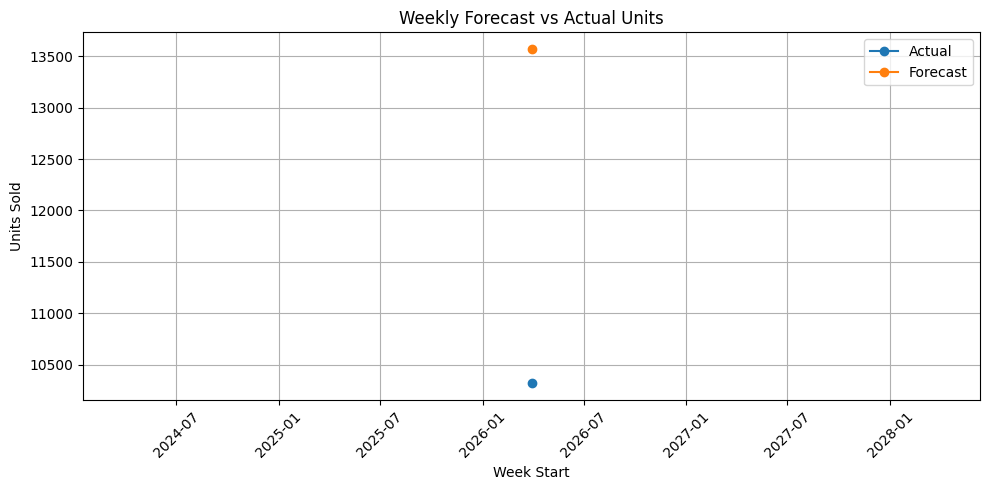

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(weekly_summary["week_start"], weekly_summary["actual_sum"], marker="o", label="Actual")
plt.plot(weekly_summary["week_start"], weekly_summary["predicted_sum"], marker="o", label="Forecast")
plt.title("Weekly Forecast vs Actual Units")
plt.xlabel("Week Start")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

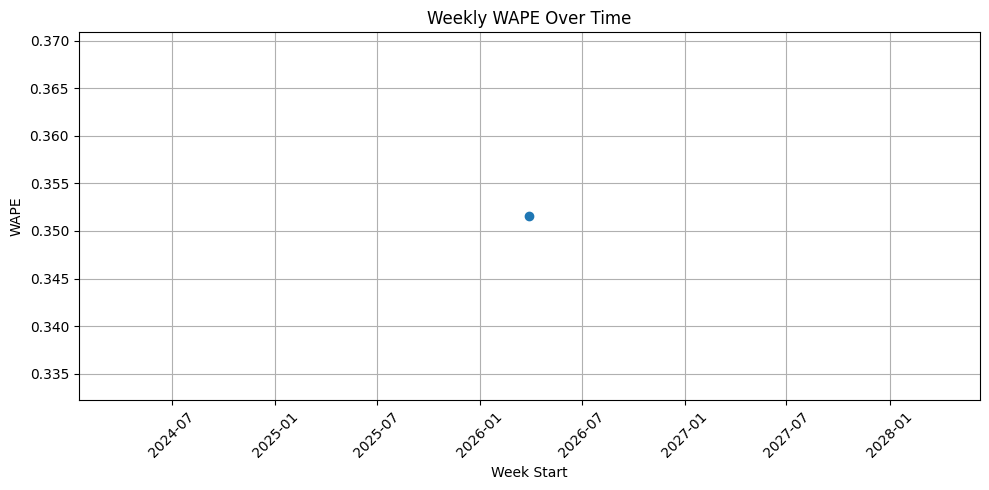

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_summary["week_start"], weekly_summary["WAPE"], marker="o")
plt.title("Weekly WAPE Over Time")
plt.xlabel("Week Start")
plt.ylabel("WAPE")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

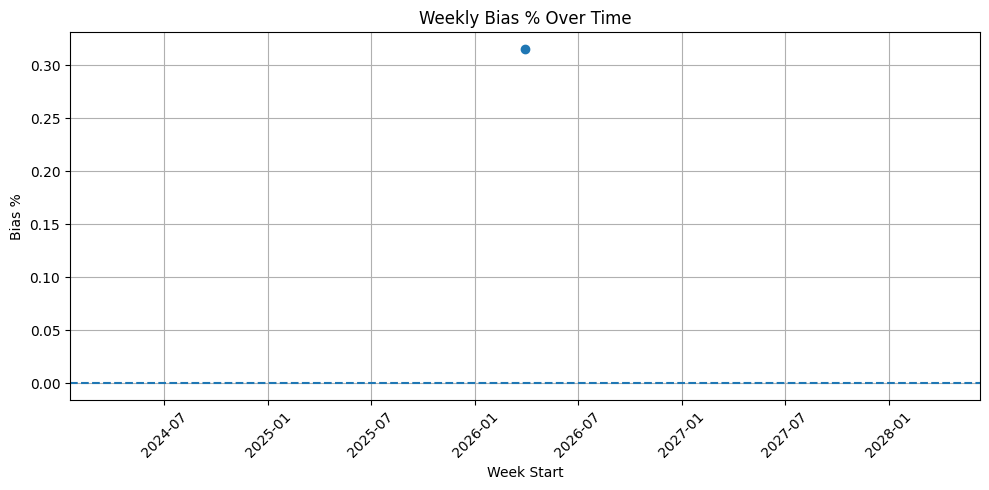

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_summary["week_start"], weekly_summary["BIAS_PCT"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Weekly Bias % Over Time")
plt.xlabel("Week Start")
plt.ylabel("Bias %")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

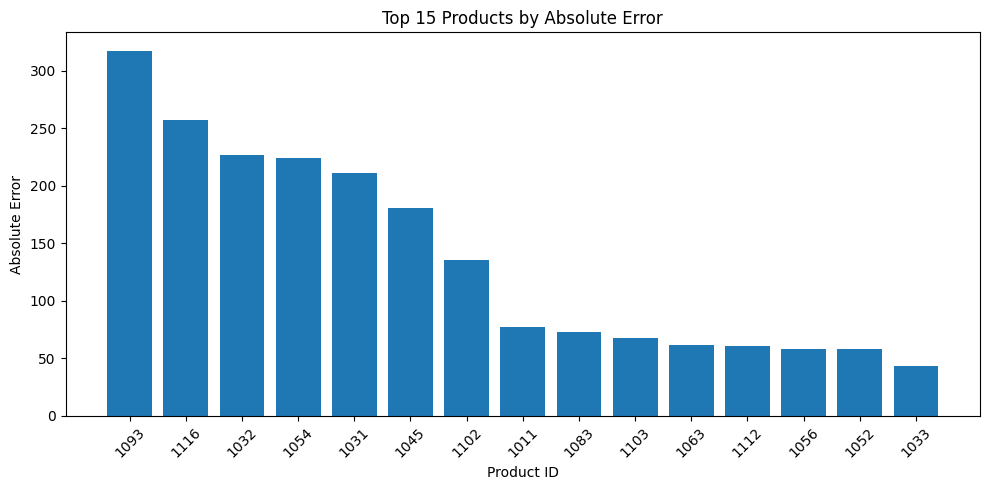

In [60]:
product_error = comparison.groupby("product_id", as_index=False).agg(
    abs_error_sum=("abs_error", "sum"),
    actual_sum=("actual_units", "sum")
)

product_error = product_error.sort_values("abs_error_sum", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(product_error["product_id"].astype(str), product_error["abs_error_sum"])
plt.title("Top 15 Products by Absolute Error")
plt.xlabel("Product ID")
plt.ylabel("Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

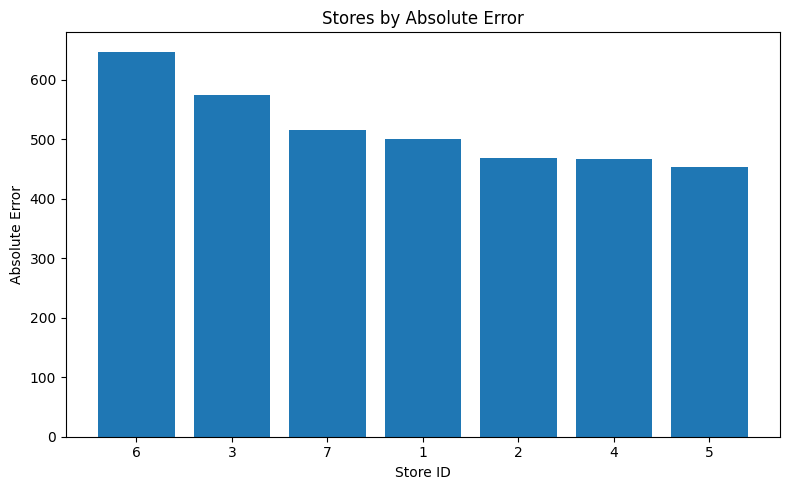

In [61]:
store_error = comparison.groupby("store_id", as_index=False).agg(
    abs_error_sum=("abs_error", "sum"),
    actual_sum=("actual_units", "sum")
)

store_error = store_error.sort_values("abs_error_sum", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(store_error["store_id"].astype(str), store_error["abs_error_sum"])
plt.title("Stores by Absolute Error")
plt.xlabel("Store ID")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

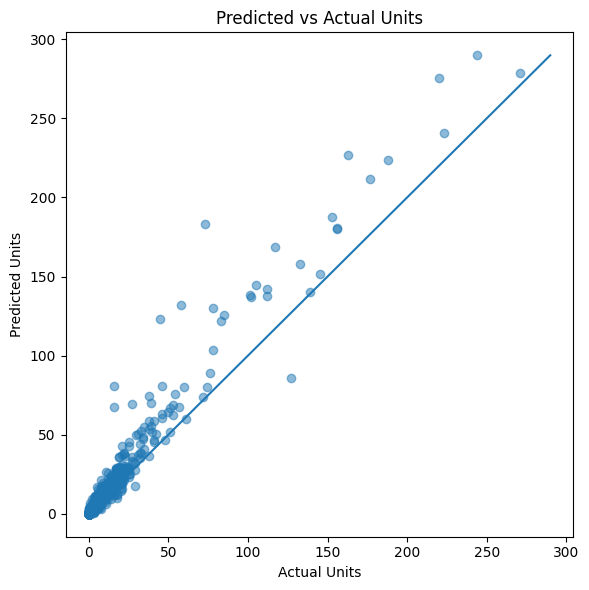

In [62]:
plt.figure(figsize=(6, 6))
plt.scatter(comparison["actual_units"], comparison["predicted_units"], alpha=0.5)
plt.xlabel("Actual Units")
plt.ylabel("Predicted Units")
plt.title("Predicted vs Actual Units")

max_val = max(
    comparison["actual_units"].max(),
    comparison["predicted_units"].max()
)
plt.plot([0, max_val], [0, max_val])
plt.tight_layout()
plt.show()

In [65]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="aws-1-eu-west-2.pooler.supabase.com",
    port=5432,
    database="postgres",
    user="data_scientist_user",
    password="data_scientist_password",
    sslmode="require"
)

query = """
SELECT *
FROM analytics.vw_daily_store_sales
LIMIT 100
"""

df = pd.read_sql(query, conn)

print(df.head())

conn.close()

OperationalError: connection to server at "aws-1-eu-west-2.pooler.supabase.com" (13.43.174.140), port 5432 failed: FATAL:  Tenant or user not found


In [67]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="aws-1-eu-west-2.pooler.supabase.com",
    port=5432,
    database="postgres",
    user="mano_fx.wxkurceflcvyjaunhath",
    password="manoFX_access_2026",
    sslmode="require"
)

query = """
SELECT *
FROM core.fact_sales
"""

df = pd.read_sql(query, conn)

print(df.head())

conn.close()

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_8545/1329293159.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


         date store_id  product_id  units_sold     price  regular_price  \
0  2025-05-18        5        1069           0  462942.0       462942.0   
1  2025-05-18        5        1070           4   64012.0        64012.0   
2  2025-05-18        5        1071           0  352764.0       352764.0   
3  2025-05-18        5        1072           3  425612.0       425612.0   
4  2025-05-18        5        1073           1  230196.0       230196.0   

   discount_pct  promo_flag promo_type    revenue  starting_inventory  \
0           0.0           0       None        0.0                   0   
1           0.0           0       None   256048.0                  25   
2           0.0           0       None        0.0                   7   
3           0.0           0       None  1276836.0                  27   
4           0.0           0       None   230196.0                   1   

   restock_qty  ending_inventory  stockout_occurred  restriction_active  \
0            0                 0   

In [68]:
df.shape

(4831680, 16)

In [70]:
df

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type
0,2025-05-18,5,1069,0,462942.0,462942.0,0.0,0,None,0.0,0,0,0,1,1,Stock Restriction
1,2025-05-18,5,1070,4,64012.0,64012.0,0.0,0,None,256048.0,25,0,21,0,0,None
2,2025-05-18,5,1071,0,352764.0,352764.0,0.0,0,None,0.0,7,0,7,0,1,Stock Restriction
3,2025-05-18,5,1072,3,425612.0,425612.0,0.0,0,None,1276836.0,27,27,24,0,0,None
4,2025-05-18,5,1073,1,230196.0,230196.0,0.0,0,None,230196.0,1,0,0,0,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4831675,2025-05-18,5,1064,1,401451.0,401451.0,0.0,0,None,401451.0,4,0,3,0,0,None
4831676,2025-05-18,5,1065,1,259407.0,259407.0,0.0,0,None,259407.0,5,0,4,0,0,None
4831677,2025-05-18,5,1066,2,52233.0,52233.0,0.0,0,None,104466.0,8,0,6,0,0,None
4831678,2025-05-18,5,1067,2,99634.0,99634.0,0.0,0,None,199268.0,6,0,4,0,0,None


In [71]:
sales

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type,city,store_size,store_type,category
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,0,0,0,1,0,NaN,Benin,Large,Mall,Televisions
1,2021-01-01,1,1001,1,445838.0,445838,0,0,NaN,445838.0,8,0,7,0,0,NaN,Benin,Large,Mall,Televisions
2,2021-01-01,1,1002,0,500410.0,500410,0,0,NaN,0.0,0,0,0,1,0,NaN,Benin,Large,Mall,Mobile Phones
3,2021-01-01,1,1002,3,500410.0,500410,0,0,NaN,1501230.0,3,0,0,0,0,NaN,Benin,Large,Mall,Mobile Phones
4,2021-01-01,1,1003,0,399365.0,399365,0,0,NaN,0.0,0,0,0,1,0,NaN,Benin,Large,Mall,Mobile Phones
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3228955,2026-04-06,7,1118,0,696237.0,696237,0,0,NaN,0.0,0,0,0,0,0,NaN,Ogwa,Small,High Street,Laptops & Computers
3228956,2026-04-06,7,1119,0,658153.0,658153,0,0,NaN,0.0,0,0,0,1,0,NaN,Ogwa,Small,High Street,Laptops & Computers
3228957,2026-04-06,7,1119,0,658153.0,658153,0,0,NaN,0.0,0,0,0,1,0,NaN,Ogwa,Small,High Street,Laptops & Computers
3228958,2026-04-06,7,1120,0,740053.0,740053,0,0,NaN,0.0,0,0,0,0,0,NaN,Ogwa,Small,High Street,Refrigerators


In [76]:
df.date.min()

datetime.date(2021, 1, 1)